# 2021+ Musteri Tercihi ve Hava Durumu Analizi

Bu notebook 2021 ve sonrasi kayitlarda musteri tercihinin (masa_grup) hava parametreleri ile iliskisini analiz etmek icin hazirlandi.

Plan:
1. Veri yukleme ve 2021+ temiz veri hazirlama
2. Parametre bazli gruplama tablolari
3. Hava kosulu x tercih dagilimi gorselleri
4. Istatistiksel iliski skorlari ve baslangic modeli

In [1]:
import os
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 120)

In [2]:
CSV_PATH = os.path.join('Veriler', 'oturum_hava_birlesik_2021_ve_sonrasi.csv')
OUTPUT_DIR = os.path.join('Outputs', 'Musteri_tercihi_hava_2021_cikti')
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_all = pd.read_csv(CSV_PATH)
df_all['tarih_dt'] = pd.to_datetime(df_all['tarih'], errors='coerce')
df = df_all.dropna(subset=['tarih_dt', 'masa_grup']).copy()

if 'outlier_flag' in df.columns:
    df = df[df['outlier_flag'].isna()].copy()

print(f'Satir sayisi: {len(df):,}')
print(f'Tarih araligi: {df["tarih_dt"].min().date()} - {df["tarih_dt"].max().date()}')
print('Masa grup kategorileri:', sorted(df['masa_grup'].dropna().unique().tolist()))
display(df.head())

Satir sayisi: 120,749
Tarih araligi: 2021-01-02 - 2025-05-28
Masa grup kategorileri: ['Bahçe', 'Paket', 'İç Salon']


,MASANO,CEKNO,acilis_datetime,kapama_datetime,oturum_sure_dk,toplam_miktar,toplam_tutar,urun_sayisi,urun_listesi,masa_grup,tarih,saat,gun_adi,ay,yil,hafta_no,merge_saati,temperature_2m,apparent_temperature,relative_humidity_2m,dewpoint_2m,precipitation,rain,showers,snowfall,windspeed_10m,winddirection_10m,cloudcover,pressure_msl,is_day,shortwave_radiation,yagis_kategori,sicaklik_aralik,outlier_flag,tarih_dt
0,B01,260306,2021-01-03 18:30:00,2021-01-03 18:43:00,13.0,4.0,59.0,2,"['FULL', 'AYRAN']",Bahçe,2021-01-03,18,Sunday,1,2021,53,2021-01-03 18:00:00,9.2,7.5,86,7.1,0.0,0.0,0.0,0.0,7.2,186,96,1021.6,0,17.0,Bulutlu,Soğuk (0–10°),NaN,2021-01-03
1,B01,260386,2021-01-04 16:52:00,2021-01-04 16:59:00,7.0,4.0,48.0,2,"['YARIM FULL', 'AYRAN']",Bahçe,2021-01-04,16,Monday,1,2021,1,2021-01-04 17:00:00,13.6,11.4,61,6.3,0.0,0.0,0.0,0.0,8.8,109,99,1014.6,1,113.0,Bulutlu,Ilık (10–20°),NaN,2021-01-04
2,B01,260388,2021-01-04 17:07:00,2021-01-04 17:12:00,5.0,2.0,34.0,2,"['3 CEYREK FULL', 'AYRAN']",Bahçe,2021-01-04,17,Monday,1,2021,1,2021-01-04 17:00:00,13.6,11.4,61,6.3,0.0,0.0,0.0,0.0,8.8,109,99,1014.6,1,113.0,Bulutlu,Ilık (10–20°),NaN,2021-01-04
3,B01,260434,2021-01-05 12:36:00,2021-01-05 12:37:00,1.0,8.0,118.0,2,"['ACISIZ FULL', 'AYRAN']",Bahçe,2021-01-05,12,Tuesday,1,2021,1,2021-01-05 13:00:00,14.4,10.5,67,8.4,0.0,0.0,0.0,0.0,23.8,209,12,1014.2,1,398.0,Açık,Ilık (10–20°),NaN,2021-01-05
4,B01,260507,2021-01-05 17:20:00,2021-01-05 17:30:00,10.0,6.0,82.0,3,"['FULL', 'SOGANSIZ', 'AYRAN']",Bahçe,2021-01-05,17,Tuesday,1,2021,1,2021-01-05 17:00:00,13.6,11.2,72,8.5,0.0,0.0,0.0,0.0,13.6,238,7,1015.5,1,140.0,Açık,Ilık (10–20°),NaN,2021-01-05


In [11]:
def normalize_text(value):
    txt = unicodedata.normalize('NFKD', str(value))
    txt = ''.join(ch for ch in txt if not unicodedata.combining(ch))
    return txt.lower().strip()

df['yagis_var'] = (pd.to_numeric(df['precipitation'], errors='coerce').fillna(0) > 0).astype(int)

df['sicaklik_grup'] = pd.cut(
    pd.to_numeric(df['temperature_2m'], errors='coerce'),
    bins=[-100, 0, 10, 20, 30, 100],
    labels=['<0', '0-10', '10-20', '20-30', '30+']
 )

df['ruzgar_grup'] = pd.cut(
    pd.to_numeric(df['windspeed_10m'], errors='coerce'),
    bins=[-0.1, 5, 15, 30, 200],
    labels=['0-5', '5-15', '15-30', '30+']
 )

df['nem_grup'] = pd.cut(
    pd.to_numeric(df['relative_humidity_2m'], errors='coerce'),
    bins=[0, 40, 60, 80, 100],
    labels=['0-40', '40-60', '60-80', '80-100'],
    include_lowest=True
 )

df['yagis_miktar_grup'] = pd.cut(
    pd.to_numeric(df['precipitation'], errors='coerce').fillna(0),
    bins=[-0.001, 0, 1, 5, 15, 200],
    labels=['0', '0-1', '1-5', '5-15', '15+'],
    include_lowest=True
 )

df['bulut_grup'] = pd.cut(
    pd.to_numeric(df['cloudcover'], errors='coerce'),
    bins=[-0.1, 20, 50, 80, 100],
    labels=['0-20', '20-50', '50-80', '80-100']
 )

if 'is_day' in df.columns:
    df['is_day'] = pd.to_numeric(df['is_day'], errors='coerce').fillna(0).astype(int)
else:
    df['is_day'] = 0

df['ay'] = pd.to_numeric(df['ay'], errors='coerce')
df['saat'] = pd.to_numeric(df['saat'], errors='coerce')

df[['yagis_var', 'sicaklik_grup', 'ruzgar_grup', 'nem_grup', 'yagis_miktar_grup', 'bulut_grup', 'is_day']].head()

,yagis_var,sicaklik_grup,ruzgar_grup,nem_grup,yagis_miktar_grup,bulut_grup,is_day
0,0,0-10,5-15,80-100,0,80-100,0
1,0,10-20,5-15,60-80,0,80-100,1
2,0,10-20,5-15,60-80,0,80-100,1
3,0,10-20,15-30,60-80,0,0-20,1
4,0,10-20,5-15,60-80,0,0-20,1


,masa_grup,oturum_sayisi,oran_yuzde
0,İç Salon,47052,38.97
1,Bahçe,37622,31.16
2,Paket,36075,29.88


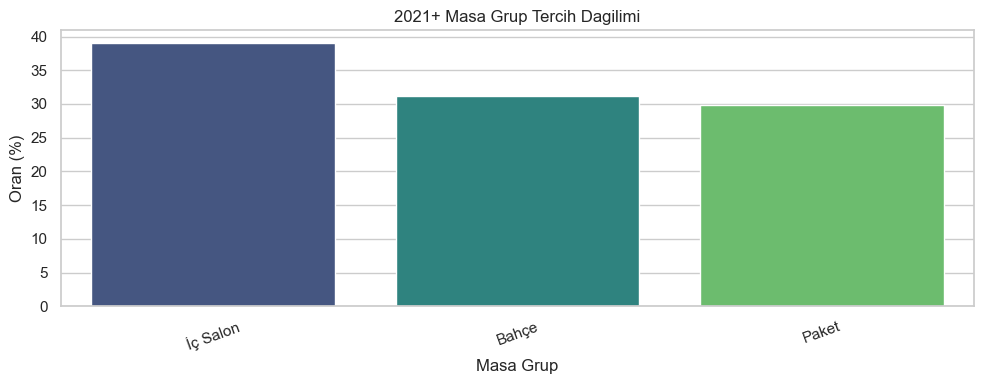

In [10]:
tercih_ozet = (
    df['masa_grup']
    .value_counts()
    .rename_axis('masa_grup')
    .reset_index(name='oturum_sayisi')
)
tercih_ozet['oran_yuzde'] = (100 * tercih_ozet['oturum_sayisi'] / tercih_ozet['oturum_sayisi'].sum()).round(2)
display(tercih_ozet)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=tercih_ozet,
    x='masa_grup',
    y='oran_yuzde',
    hue='masa_grup',
    palette='viridis',
    dodge=False,
    legend=False,
    ax=ax,
 )
ax.set_title('2021+ Masa Grup Tercih Dagilimi')
ax.set_xlabel('Masa Grup')
ax.set_ylabel('Oran (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [12]:
def grouped_share_table(data, group_col, target_col='masa_grup', min_count=30):
    temp = data[[group_col, target_col]].dropna().copy()
    counts = temp.groupby(group_col).size()
    valid = counts[counts >= min_count].index
    temp = temp[temp[group_col].isin(valid)]

    if temp.empty:
        return pd.DataFrame()

    table = pd.crosstab(temp[group_col], temp[target_col], normalize='index') * 100
    return table.round(2).sort_index()

# Tum gruplamalar parametre tabanli tutuldu.
param_cols = [
    'yagis_kategori',
    'yagis_miktar_grup',
    'sicaklik_aralik',
    'sicaklik_grup',
    'nem_grup',
    'ruzgar_grup',
    'bulut_grup',
    'is_day',
]

group_tables = {}
for col in param_cols:
    if col in df.columns:
        table = grouped_share_table(df, col)
        if not table.empty:
            group_tables[col] = table
            print(f'\n### {col} x masa_grup (%)')
            display(table)


### yagis_kategori x masa_grup (%)


masa_grup,Bahçe,Paket,İç Salon
yagis_kategori,,,
Açık,36.38,28.86,34.76
Bulutlu,25.80,30.70,43.50
Kar,4.91,47.04,48.06
Sağanak,17.48,35.92,46.60
Yağmur,24.65,30.84,44.51



### yagis_miktar_grup x masa_grup (%)


masa_grup,Bahçe,Paket,İç Salon
yagis_miktar_grup,,,
0,32.67,29.51,37.82
0-1,24.28,31.03,44.69
1-5,18.25,36.88,44.87
5-15,15.93,33.63,50.44



### sicaklik_aralik x masa_grup (%)


...

masa_grup,Bahçe,Paket,İç Salon
ruzgar_grup,,,
0-5,29.68,30.11,40.21
5-15,30.43,30.62,38.95
15-30,32.19,29.05,38.76
30+,26.83,32.76,40.42



### bulut_grup x masa_grup (%)


masa_grup,Bahçe,Paket,İç Salon
bulut_grup,,,
0-20,37.46,28.41,34.13
20-50,36.18,29.34,34.48
50-80,32.50,29.58,37.92
80-100,23.16,31.49,45.35



### is_day x masa_grup (%)


masa_grup,Bahçe,Paket,İç Salon
is_day,,,
0,20.91,35.44,43.65
1,33.21,28.76,38.03


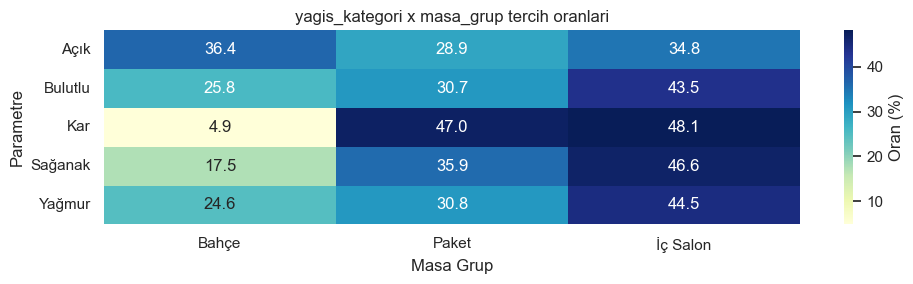

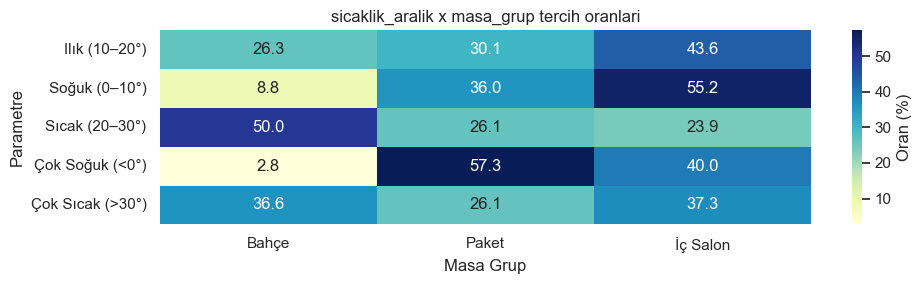

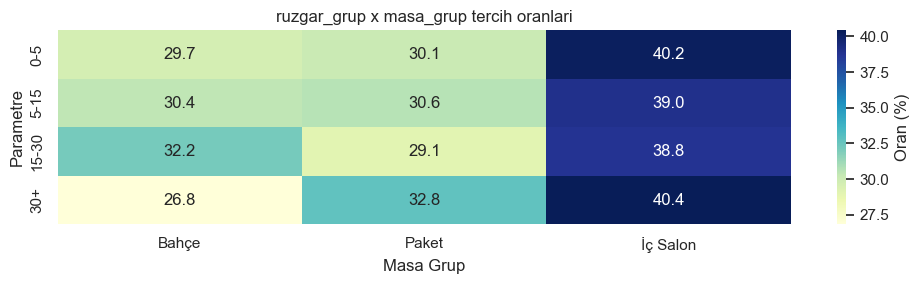

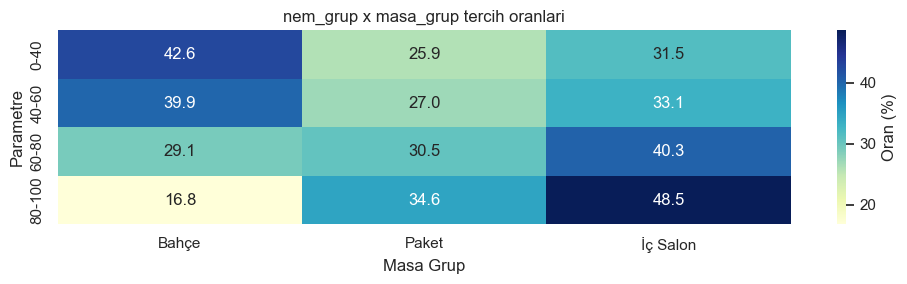

In [ ]:
def plot_share_heatmap(table, title):
    plt.figure(figsize=(10, max(3, 0.45 * len(table))))
    sns.heatmap(table, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Oran (%)'})
    plt.title(title)
    plt.xlabel('Masa Grup')
    plt.ylabel('Parametre')
    plt.tight_layout()
    plt.show()

for key in [
    'yagis_kategori',
    'yagis_miktar_grup',
    'sicaklik_aralik',
    'sicaklik_grup',
    'nem_grup',
    'ruzgar_grup',
    'bulut_grup',
    'is_day',
]:
    if key in group_tables:
        plot_share_heatmap(group_tables[key], f'{key} x masa_grup tercih oranlari')

In [13]:
def cramers_v_from_crosstab(ct):
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    if n == 0:
        return np.nan

    r, k = ct.shape
    denom = min(k - 1, r - 1)
    if denom == 0:
        return np.nan

    return np.sqrt((chi2 / n) / denom)

impact_rows = []
for col in [
    'yagis_kategori',
    'yagis_miktar_grup',
    'sicaklik_aralik',
    'sicaklik_grup',
    'nem_grup',
    'ruzgar_grup',
    'bulut_grup',
    'is_day',
]:
    if col not in df.columns:
        continue

    tmp = df[[col, 'masa_grup']].dropna()
    if len(tmp) < 100:
        continue

    ct = pd.crosstab(tmp[col], tmp['masa_grup'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue

    chi2, p_val, _, _ = chi2_contingency(ct)
    impact_rows.append({
        'parametre': col,
        'n': int(ct.values.sum()),
        'p_degeri': p_val,
        'cramers_v': cramers_v_from_crosstab(ct),
    })

impact_df = (
    pd.DataFrame(impact_rows)
    .sort_values(['cramers_v', 'p_degeri'], ascending=[False, True])
    .reset_index(drop=True)
)

display(impact_df)

,parametre,n,p_degeri,cramers_v
0,sicaklik_aralik,120749,0.000000e+00,0.245058
1,sicaklik_grup,120749,0.000000e+00,0.245058
2,nem_grup,120749,0.000000e+00,0.129958
3,bulut_grup,120749,0.000000e+00,0.103135
4,is_day,120749,2.962018e-261,0.099680
5,yagis_kategori,120749,0.000000e+00,0.095668
6,yagis_miktar_grup,120749,2.738056e-154,0.054957
7,ruzgar_grup,120749,3.117204e-18,0.019808


In [8]:
unique_labels = [x for x in df['masa_grup'].dropna().unique()]
norm_map = {lbl: normalize_text(lbl) for lbl in unique_labels}

outdoor_label = next((lbl for lbl, nrm in norm_map.items() if 'bahce' in nrm), None)
indoor_label = next((lbl for lbl, nrm in norm_map.items() if ('ic salon' in nrm) or ('icsalon' in nrm)), None)

if outdoor_label is not None and indoor_label is not None:
    bin_df = df[df['masa_grup'].isin([outdoor_label, indoor_label])].copy()
    bin_df['hedef_dis_mekan'] = (bin_df['masa_grup'] == outdoor_label).astype(int)

    num_features = [
        c for c in [
            'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
            'precipitation', 'rain', 'snowfall', 'windspeed_10m',
            'cloudcover', 'pressure_msl', 'shortwave_radiation', 'saat', 'ay'
        ] if c in bin_df.columns
    ]
    cat_features = [c for c in ['yagis_kategori', 'sicaklik_aralik', 'gun_adi'] if c in bin_df.columns]

    X = bin_df[num_features + cat_features].copy()
    y = bin_df['hedef_dis_mekan']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('scale', StandardScaler())]), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ],
        remainder='drop',
    )

    model = Pipeline(
        steps=[
            ('prep', preprocessor),
            ('clf', LogisticRegression(max_iter=1200, class_weight='balanced')),
        ]
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, prob)
    print(f'Karsilastirma: {outdoor_label} vs {indoor_label}')
    print(f'AUC: {auc:.4f}')
    print(classification_report(y_test, pred, digits=4))
else:
    print('Bahce/Ic Salon etiketleri otomatik tespit edilemedi, model adimi atlandi.')

Karsilastirma: Bahçe vs İç Salon
AUC: 0.7497
              precision    recall  f1-score   support

           0     0.7443    0.7009    0.7219     11763
           1     0.6514    0.6988    0.6743      9406

    accuracy                         0.7000     21169
   macro avg     0.6978    0.6999    0.6981     21169
weighted avg     0.7030    0.7000    0.7008     21169



In [14]:
import json
import glob

long_rows = []
for parametre, table in group_tables.items():
    table_reset = table.reset_index()
    parametre_deger_col = table_reset.columns[0]

    melted = table_reset.melt(
        id_vars=[parametre_deger_col],
        var_name='masa_grup',
        value_name='oran_yuzde',
    )

    grup_sayilari = df.groupby(parametre).size().to_dict()
    melted['grup_oturum_sayisi'] = melted[parametre_deger_col].map(grup_sayilari).astype('Int64')
    melted = melted.rename(columns={parametre_deger_col: 'parametre_degeri'})
    melted.insert(0, 'parametre', parametre)
    long_rows.append(melted)

if long_rows:
    grouped_long_df = pd.concat(long_rows, ignore_index=True)
else:
    grouped_long_df = pd.DataFrame(columns=[
        'parametre', 'parametre_degeri', 'masa_grup', 'oran_yuzde', 'grup_oturum_sayisi'
    ])

dominant_pref_df = (
    grouped_long_df
    .sort_values(['parametre', 'parametre_degeri', 'oran_yuzde'], ascending=[True, True, False])
    .groupby(['parametre', 'parametre_degeri'], as_index=False)
    .first()
    .rename(columns={
        'masa_grup': 'baskin_tercih',
        'oran_yuzde': 'baskin_tercih_oran_yuzde',
    })
    [['parametre', 'parametre_degeri', 'baskin_tercih', 'baskin_tercih_oran_yuzde', 'grup_oturum_sayisi']]
)

analysis_payload = {
    'meta': {
        'kaynak_dosya': CSV_PATH,
        'uretim_zamani': pd.Timestamp.now().isoformat(),
        'satir_sayisi': int(len(df)),
        'parametreler': sorted(group_tables.keys()),
    },
    'parametre_tabanli_oranlar': grouped_long_df.to_dict(orient='records'),
    'baskin_tercih_ozeti': dominant_pref_df.to_dict(orient='records'),
    'parametre_etki_skorlari': impact_df.to_dict(orient='records'),
}

consolidated_path = os.path.join(OUTPUT_DIR, 'parametre_tabanli_gruplama_analizi.json')
with open(consolidated_path, 'w', encoding='utf-8') as f:
    json.dump(analysis_payload, f, ensure_ascii=False, indent=2, default=str)

# Onceki coklu csv ciktilarini temizle
for eski_dosya in glob.glob(os.path.join(OUTPUT_DIR, 'gruplama_*.csv')):
    os.remove(eski_dosya)

eski_etki_csv = os.path.join(OUTPUT_DIR, 'parametre_etki_skorlari.csv')
if os.path.exists(eski_etki_csv):
    os.remove(eski_etki_csv)

print('Tek dosya cikti:', consolidated_path)
display(grouped_long_df.head(12))
display(dominant_pref_df.head(12))

Tek dosya cikti: Outputs\Musteri_tercihi_hava_2021_cikti\parametre_tabanli_gruplama_analizi.json


,parametre,parametre_degeri,masa_grup,oran_yuzde,grup_oturum_sayisi
0,yagis_kategori,Açık,Bahçe,36.38,65462
1,yagis_kategori,Bulutlu,Bahçe,25.80,35253
2,yagis_kategori,Kar,Bahçe,4.91,1080
3,yagis_kategori,Sağanak,Bahçe,17.48,103
4,yagis_kategori,Yağmur,Bahçe,24.65,18829
5,yagis_kategori,Açık,Paket,28.86,65462
6,yagis_kategori,Bulutlu,Paket,30.70,35253
7,yagis_kategori,Kar,Paket,47.04,1080
8,yagis_kategori,Sağanak,Paket,35.92,103
9,yagis_kategori,Yağmur,Paket,30.84,18829


,parametre,parametre_degeri,baskin_tercih,baskin_tercih_oran_yuzde,grup_oturum_sayisi
0,bulut_grup,0-20,Bahçe,37.46,42052
1,bulut_grup,20-50,Bahçe,36.18,18265
2,bulut_grup,50-80,İç Salon,37.92,13521
3,bulut_grup,80-100,İç Salon,45.35,46911
4,is_day,0,İç Salon,43.65,20131
5,is_day,1,İç Salon,38.03,100618
6,nem_grup,0-40,Bahçe,42.58,6473
7,nem_grup,40-60,Bahçe,39.92,39701
8,nem_grup,60-80,İç Salon,40.31,52479
9,nem_grup,80-100,İç Salon,48.52,22096


## Sonraki adimlar

- Saat dilimi bazli (sabah/ogle/aksam) tercih oranlari
- Sadece yagisli gunlerde Bahce kaybi tahmini
- Donemsel (2021, 2022, 2023, ...) etki degisimlerinin izlenmesi